<a href="https://www.kaggle.com/code/arnoldaijuka/basotho-wool-dataset?scriptVersionId=346085396" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 1. Import Libraries & Load Dataset

In [1]:
# Import necessary Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import missingno as msno

In [2]:
# Load Dataset
wool_df = pd.read_csv("/kaggle/input/datasets/arnoldaijuka/basotho-wool/basotho_wool.csv")

wool_df.tail(5)

,ref_period_id,ref_year,ref_month,period,reporter_code,reporter_iso,reporter_desc,flow_code,classification_code,cmd_code,...,is_qty_estimated,alt_qty_unit_code,alt_qty_unit_abbr,alt_qty,net_wgt,is_net_wgt_estimated,cifvalue,fobvalue,primary_value,legacy_estimation_flag
288,20240901,2024,9,202409,710,ZAF,South Africa,M,H6,5101,...,False,8,kg,469076.0,469076.0,False,NaN,3193338.747,3193338.747,0
289,20241001,2024,10,202410,710,ZAF,South Africa,M,H6,5101,...,False,8,kg,1203420.0,1203420.0,False,NaN,8223835.262,8223835.262,0
290,20241101,2024,11,202411,710,ZAF,South Africa,M,H6,5101,...,False,8,kg,1160980.0,1160980.0,False,NaN,7769662.732,7769662.732,0
291,20241201,2024,12,202412,156,CHN,China,M,H6,5101,...,False,8,kg,65015.0,65015.0,False,496548.0,NaN,496548.000,0
292,20241201,2024,12,202412,710,ZAF,South Africa,M,H6,5101,...,False,8,kg,957722.0,957722.0,False,NaN,6322553.168,6322553.168,0


# 2. Initial data exploration

In [3]:
# Check dataset shape (Number of rows and columns)
print(f'The dataset has {wool_df.shape[0]} rows and {wool_df.shape[1]} columns.')

The dataset has 293 rows and 24 columns.


In [4]:
# Determine the types for each column
wool_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ref_period_id           293 non-null    int64  
 1   ref_year                293 non-null    int64  
 2   ref_month               293 non-null    int64  
 3   period                  293 non-null    int64  
 4   reporter_code           293 non-null    int64  
 5   reporter_iso            293 non-null    object 
 6   reporter_desc           293 non-null    object 
 7   flow_code               293 non-null    object 
 8   classification_code     293 non-null    object 
 9   cmd_code                293 non-null    int64  
 10  cmd_desc                293 non-null    object 
 11  qty_unit_code           293 non-null    int64  
 12  qty_unit_abbr           266 non-null    object 
 13  qty                     292 non-null    float64
 14  is_qty_estimated        293 non-null    bo

<Axes: >

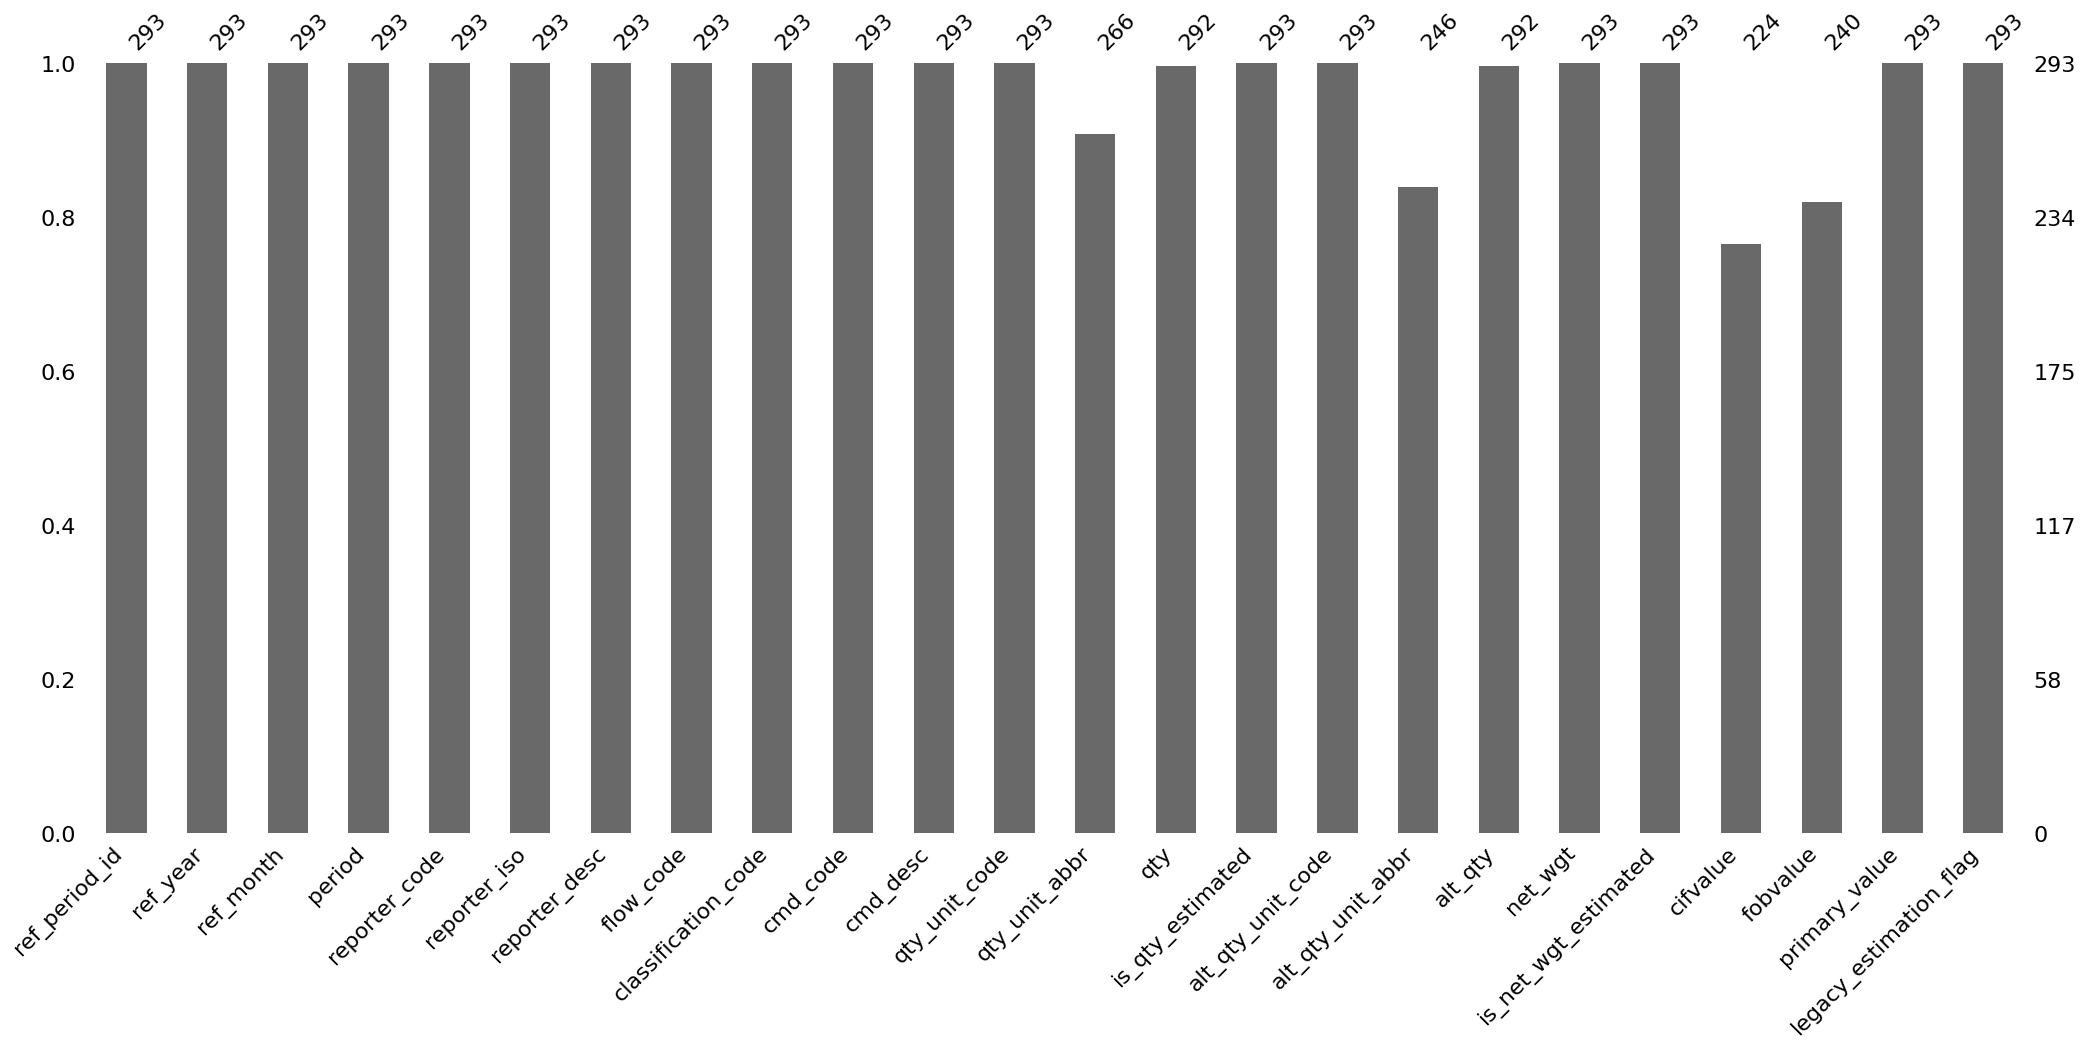

In [5]:
# Visualize all missing fields using missingno
msno.bar(wool_df)

In [6]:
# Count the number of missing values in each column
missing_values = wool_df.isnull().sum().sort_values(ascending=False)
missing_percentage = (missing_values / len(wool_df)) * 100
print(pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage}))

                        Missing Values  Percentage
cifvalue                            69   23.549488
fobvalue                            53   18.088737
alt_qty_unit_abbr                   47   16.040956
qty_unit_abbr                       27    9.215017
qty                                  1    0.341297
alt_qty                              1    0.341297
ref_period_id                        0    0.000000
ref_year                             0    0.000000
flow_code                            0    0.000000
reporter_desc                        0    0.000000
reporter_iso                         0    0.000000
reporter_code                        0    0.000000
period                               0    0.000000
ref_month                            0    0.000000
classification_code                  0    0.000000
cmd_code                             0    0.000000
alt_qty_unit_code                    0    0.000000
is_qty_estimated                     0    0.000000
cmd_desc                       

In [7]:
# Check the number of duplicates
print(wool_df.duplicated())

0      False
1      False
2      False
3      False
4      False
       ...  
288    False
289    False
290    False
291    False
292    False
Length: 293, dtype: bool


# 3. Data Exploration & Visualization of Insights

## 3.1 Overall Growth Insight

In [8]:
# Group values based on year (ref_year) and add up all the values of each year to create dataframe annual_sales
annual_sales = wool_df.groupby(['ref_year'])['primary_value'].sum().reset_index()
annual_sales.head()

,ref_year,primary_value
0,2010,4.031722e+06
1,2011,7.846964e+06
2,2012,1.071655e+07
3,2013,9.699242e+06
4,2014,8.924303e+06


In [9]:
# Determine overall growth (sales from 2024 - sales from 2010 / sales from 2010 ) * 100

# Extract the latest year using max function and oldest year using min function
latest = annual_sales['ref_year'].max()
oldest = annual_sales['ref_year'].min()

# Extract the latest year sales results and first year sales results using loc
latest_year_sales = annual_sales.loc[annual_sales['ref_year'] == latest, 'primary_value'].item()
first_year_sales = annual_sales.loc[annual_sales['ref_year'] == oldest, 'primary_value'].item()

# Determine overall growth using formula (New - Old / Old) * 100
overall_growth = ((latest_year_sales - first_year_sales)/ first_year_sales)*100
overall_growth = int(overall_growth)

print(f'Overall Growth over the 15 years is {overall_growth} %')

Overall Growth over the 15 years is 1421 %


### 3.1.1 Growth Visualization Diagram

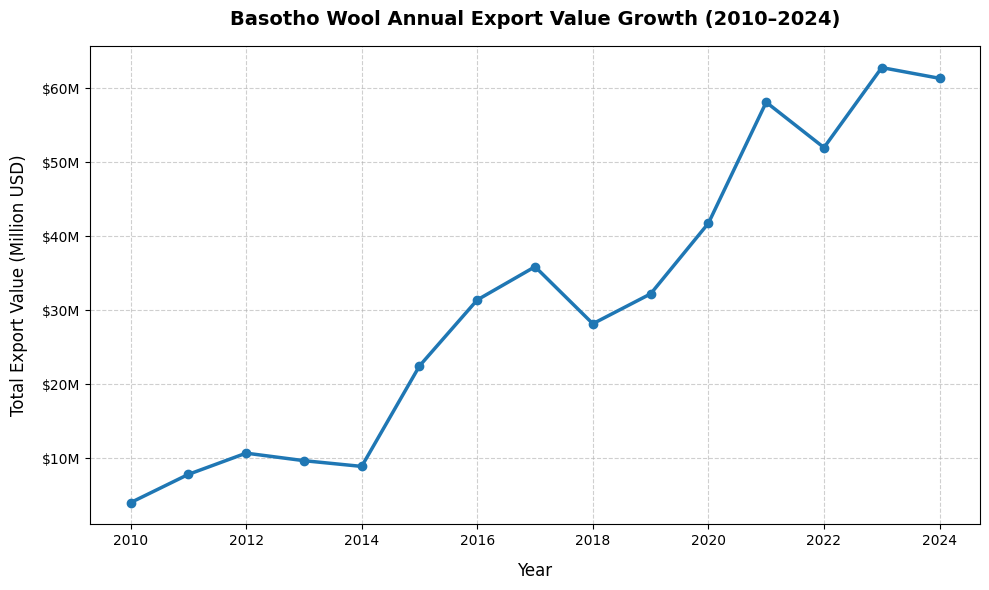

In [10]:
# Line chart to show growth over the years
x = annual_sales['ref_year']
y = annual_sales['primary_value'] / 1e6


plt.figure(figsize=(10, 6))
plt.plot(x, y, marker='o', linewidth=2.5, color='#1f77b4', markersize=6)

# Standardize X-Axis
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Standardize Y-Axis (Currency)
# Formats the ticks as "$X M" (e.g., $40M, $60M) with 0 decimal places
formatter = ticker.StrMethodFormatter('${x:,.0f}M')
plt.gca().yaxis.set_major_formatter(formatter)

# 6. Add labels, title, and grid
plt.title('Basotho Wool Annual Export Value Growth (2010–2024)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12, labelpad=10)
plt.ylabel('Total Export Value (Million USD)', fontsize=12, labelpad=10)

# A subtle dashed grid makes it easier to read values across the chart
plt.grid(True, linestyle='--', alpha=0.6)

# Automatically adjust padding so nothing gets cut off when saving/displaying
plt.tight_layout()


plt.show()

## 3.2 Market Share Insight

In [11]:
# Largest contributor to sales (Country statistic)
country_exports = wool_df.groupby(['reporter_desc'])['primary_value'].sum().reset_index()

country_exports.head()

,reporter_desc,primary_value
0,China,1.733792e+08
1,India,1.191202e+07
2,South Africa,2.819060e+08
3,Uruguay,2.145522e+05


### 3.2.1 Market Share Visualization Insight

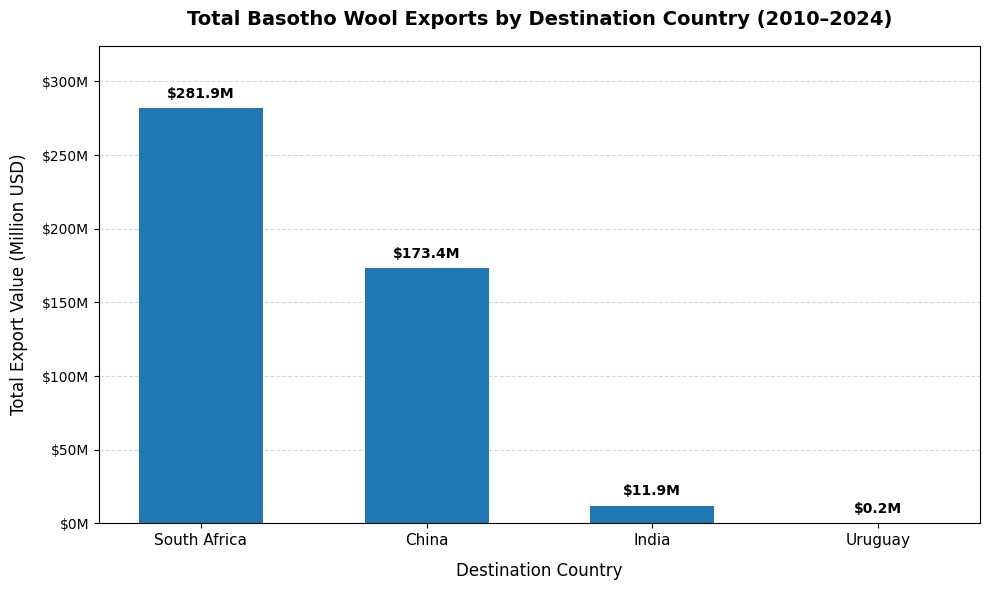

In [12]:
# Plot a bar chart

# Sort the dataframe from highest to lowest before plotting for a cleaner look
country_exports = country_exports.sort_values(by='primary_value', ascending=False)

# Set the figure size
plt.figure(figsize=(10, 6))

# Create the bar plot directly with matplotlib, scaling the values to Millions
bars = plt.bar(
    country_exports['reporter_desc'], 
    country_exports['primary_value'] / 1e6, # Divide by 1 million
    color='#1f77b4', 
    width=0.55 # Slightly thinner bars look more modern
)

# Add clear, descriptive titles and labels
plt.title('Total Basotho Wool Exports by Destination Country (2010–2024)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Destination Country', fontsize=12, labelpad=10)
plt.ylabel('Total Export Value (Million USD)', fontsize=12, labelpad=10)

# Format the Y-axis to display clean currency values (e.g., $100M)
formatter = ticker.StrMethodFormatter('${x:,.0f}M')
plt.gca().yaxis.set_major_formatter(formatter)

# Add exact text labels directly on top of the bars
for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.text(
            bar.get_x() + bar.get_width() / 2.,  # Center the text horizontally
            height + 5,                          # Push text slightly above the bar
            f'${height:,.1f}M',                 # Format the text with 1 decimal place
            ha='center',                         # Horizontal alignment
            va='bottom',                         # Vertical alignment
            fontsize=10,
            fontweight='bold'
        )

# Add extra headroom at the top of the chart so labels don't get cut off
plt.ylim(0, max(country_exports['primary_value'] / 1e6) * 1.15)

# Force the x-axis text to be horizontal instead of rotated
plt.xticks(rotation=0, fontsize=11)

# Add a subtle horizontal grid behind the bars to help track values
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.gca().set_axisbelow(True) # Ensures grid stays *behind* the bars

# Automatically adjust padding
plt.tight_layout()

# Display the polished chart
plt.show()

## 3.3 Unit Economics Insights

In [13]:
# Unit Economics
unit_per_kg_price = wool_df.groupby(['reporter_desc'])[['primary_value', 'net_wgt']].sum().reset_index()
unit_per_kg_price['cost_per_unit'] = unit_per_kg_price['primary_value'] / unit_per_kg_price['net_wgt'] 
unit_per_kg_price.head()

,reporter_desc,primary_value,net_wgt,cost_per_unit
0,China,1.733792e+08,2.421885e+07,7.158854
1,India,1.191202e+07,1.098982e+06,10.839142
2,South Africa,2.819060e+08,6.315293e+07,4.463863
3,Uruguay,2.145522e+05,4.998370e+04,4.292443


### 3.3.1 Visualization of unit economics

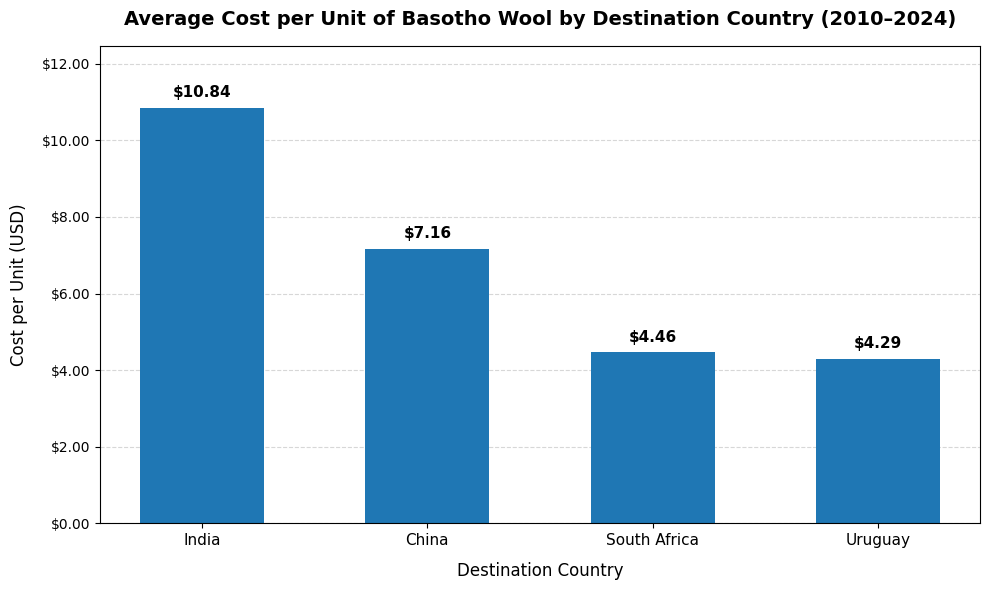

In [14]:
# Sort the dataframe from highest to lowest before plotting for a cleaner look
unit_per_kg_price = unit_per_kg_price.sort_values(by='cost_per_unit', ascending=False)

# Set the figure size
plt.figure(figsize=(10, 6))

# Create the bar plot directly with matplotlib
bars = plt.bar(
    unit_per_kg_price['reporter_desc'], 
    unit_per_kg_price['cost_per_unit'], 
    color='#1f77b4', 
    width=0.55 # Slightly thinner bars look more modern
)

# Add clear, descriptive titles and labels
plt.title('Average Cost per Unit of Basotho Wool by Destination Country (2010–2024)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Destination Country', fontsize=12, labelpad=10)
plt.ylabel('Cost per Unit (USD)', fontsize=12, labelpad=10)

# Format the Y-axis to display clean currency values 
formatter = ticker.StrMethodFormatter('${x:,.2f}')
plt.gca().yaxis.set_major_formatter(formatter)

# Add exact text labels directly on top of the bars
for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.text(
            bar.get_x() + bar.get_width() / 2.,  # Center the text horizontally
            height + 0.2,                        # FIX: Reduced push height to 0.2 to fit the smaller scale
            f'${height:,.2f}',                   # FIX: Formatted for 2 decimal places with no "M"
            ha='center',                         # Horizontal alignment
            va='bottom',                         # Vertical alignment
            fontsize=11,
            fontweight='bold'
        )

# Add extra headroom at the top of the chart so labels don't get cut off
plt.ylim(0, max(unit_per_kg_price['cost_per_unit']) * 1.15)

# Force the x-axis text to be horizontal instead of rotated
plt.xticks(rotation=0, fontsize=11)

# Add a subtle horizontal grid behind the bars to help track values
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.gca().set_axisbelow(True) # Ensures grid stays *behind* the bars

# Automatically adjust padding
plt.tight_layout()

# Display the polished chart
plt.show()